In [2]:
import pandas as pd          
import numpy as np          
import matplotlib.pyplot as plt   
import seaborn as sns  


Датасет - House Prices (https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques). В датасете размещена информация о цене продажи домов в США(c 2006 по 2011 год), а также еще 80 признаков, которые могли влиять на цену продажи('SalePrice' - целевая переменная)

In [3]:
df = pd.read_csv("датасет/train.csv")


In [4]:
print('ПУНКТ "A"')
pd.set_option('display.max_rows', None)    # показать все строки (если нужно)
pd.set_option('display.max_columns', None) # показать все столбцы
print('head()')
print(df.head())
print('tail()')
print(df.tail())
print('shape')
print(df.shape)
print('info()')
print(df.info())
print('describe()')
print(df.describe())
print('describe(include="object")')
print(df.describe(include='object'))
pd.set_option('display.max_rows', None)    # показать все строки (если нужно)
pd.set_option('display.max_columns', None) # показать все столбцы
print('isnull().sum()')
print(df.isnull().sum())

ПУНКТ "A"
head()
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0       Norm     1Fam     2Story      

C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\1886422296.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


In [5]:
print(df['SalePrice'])

0       208500
1       181500
2       223500
3       140000
4       250000
5       143000
6       307000
7       200000
8       129900
9       118000
10      129500
11      345000
12      144000
13      279500
14      157000
15      132000
16      149000
17       90000
18      159000
19      139000
20      325300
21      139400
22      230000
23      129900
24      154000
25      256300
26      134800
27      306000
28      207500
29       68500
30       40000
31      149350
32      179900
33      165500
34      277500
35      309000
36      145000
37      153000
38      109000
39       82000
40      160000
41      170000
42      144000
43      130250
44      141000
45      319900
46      239686
47      249700
48      113000
49      127000
50      177000
51      114500
52      110000
53      385000
54      130000
55      180500
56      172500
57      196500
58      438780
59      124900
60      158000
61      101000
62      202500
63      140000
64      219500
65      317000
66      18

In [6]:
print('ПУНКТ "Б"')
print('Нахождение пропусков по колонкам')
df2 = df.copy()#создаем копию исходного датафрейма для того чтобы сравнить корреляцию до внесения изменений в пропуски и после
# Получаем Series с количеством пропусков
df_null = df.columns[df2.isnull().sum()>0].tolist()
print(df2[df_null].isnull().sum())
if 'SalePrice' not in df_null:
    df_null.append('SalePrice')
df_null_nums = df2[df_null].select_dtypes(include = [np.number]).columns.tolist()
print(df2[df_null_nums].isnull().sum()) #смотрим количество пропусков по числовым признакам
df_null_nums.extend(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'])
matrix_corr = df2[df_null_nums].corr()
print(matrix_corr['SalePrice']) #находим корреляцию этих признаков с ценой, чтобы определить стоит ли тратить много времени на то чтобы думать как их заполнить






ПУНКТ "Б"
Нахождение пропусков по колонкам
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
SalePrice        0
dtype: int64
LotFrontage    0.351799
MasVnrArea     0.477493
GarageYrBlt    0.486362
SalePrice      1.000000
LotFrontage    0.351799
MasVnrArea     0.477493
GarageYrBlt    0.486362
Name: SalePrice, dtype: float64


Мы видим то числовы признаки, которые имеют пропуски относительно важны(корреляция ~ 0,35-0,5). Поэтому важно грамотно их заполнить(это признаки: LotFrontage, MasVnrArea, GarageYrBlt)




LotFrontage - это длина участков. Поэтому в теории она может зависеть от района, где расположен дом(где-то участки в среднем длиннее, а где-то наоборот)

25


C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\1716746709.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='LotFrontage', y='Neighborhood', palette='viridis')


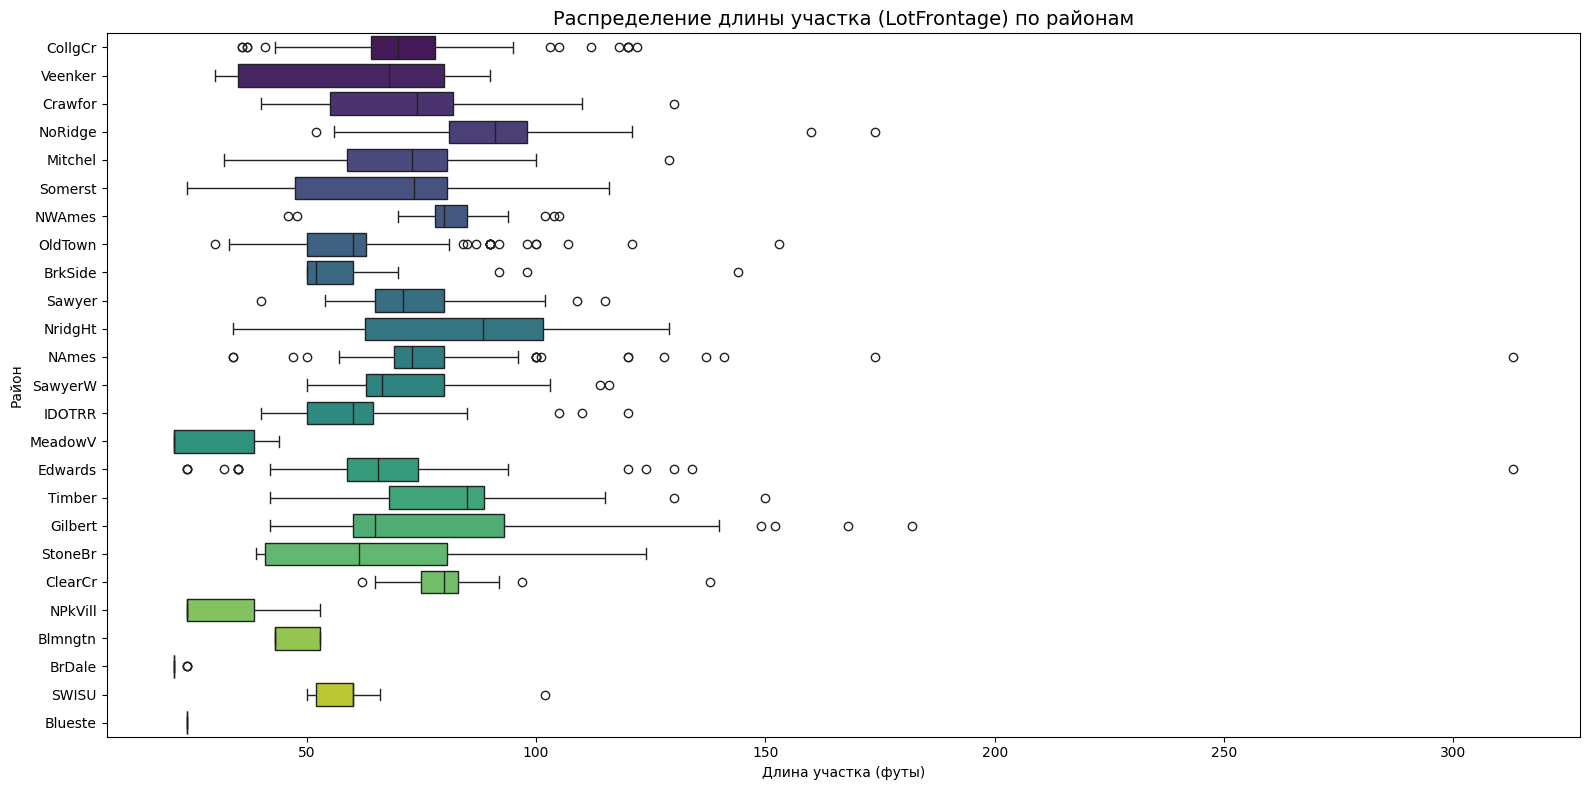

In [7]:
#определим зависит ли длина участка от района где он расположен
print(df2['Neighborhood'].nunique())#вычисляем количество районов чтобы понять насколько их много и можем ли мы легко отобразить для них boxplot


# Настраиваем размер графика (чем больше районов, тем шире)
plt.figure(figsize=(16, 8))

# Строим горизонтальный boxplot для удобства чтения названий районов
sns.boxplot(data=df2, x='LotFrontage', y='Neighborhood', palette='viridis')

# Добавляем заголовок и подписи
plt.title('Распределение длины участка (LotFrontage) по районам', fontsize=14)
plt.xlabel('Длина участка (футы)')
plt.ylabel('Район')

# Показываем график
plt.tight_layout()
plt.show()

Исходя из BoxPlot можно увидеть, что длина участков во всех районах варьируется плюс-минус в одном диапозоне(если я правильно это интерпритировал), поэтому я считаю что пропущенные значения по данному признаку можно заполнить медианной длиной участка по всем районам

In [8]:
#заполнение пропущенных участков глобальной медианой
df2['LotFrontage'] = df2['LotFrontage'].fillna(df2['LotFrontage'].median())
print(df2['LotFrontage'].isnull().sum()) #проверяем заполнились они или нет

0


MasVnrArea - это площадь каменной облицовки, если значение не указано - значит скорее всего ее вообще нету, значит площадь облицовки будет равна нулю, а значит все пропуски мы можем заполнить константой = 0

In [9]:
df2['MasVnrArea'] = df2['MasVnrArea'].fillna(0)
#проверяем заполнилось или нет
print(df2['MasVnrArea'].isnull().sum())

0


GarageYrBlt - это год постройки гаража. Пропуск по данному признаку коррелирует с пропусками в других признаках связанных с гаражем, значит можно сделать вывод что там где пропуски - гараж отсутствует. Для этого можно добавить отдельный столбец, который будет отображать есть ли на участке гараж или нет. А для уже существующего я попробую попробую подобрать константу для заполнения пропусков, чтобы после заполнения корреляция с ценой сильной не поменялась

In [10]:
# Заменяем все нули на 2000
df2['GarageYrBlt'] = df2['GarageYrBlt'].fillna(1970)
#проверяем заполнилось или нет
print(df2['GarageYrBlt'].isnull().sum())
#проверяем насколько сильно поменялась корреляция тех признаков, которые мы заполнили пропусками
matrix_corr1 = df[['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'SalePrice']].corr()
matrix_corr2 = df2[['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'SalePrice']].corr()
print(matrix_corr1['SalePrice'])
print(matrix_corr2['SalePrice'])

0
LotFrontage    0.351799
MasVnrArea     0.477493
GarageYrBlt    0.486362
SalePrice      1.000000
Name: SalePrice, dtype: float64
LotFrontage    0.334771
MasVnrArea     0.472614
GarageYrBlt    0.487798
SalePrice      1.000000
Name: SalePrice, dtype: float64


Мы видим то что мы хорошо заполнили пропуски, поскольку после внесения изменений корреляция этих признаков с ценой дома не сильно поменялась. Можно сделать вывод, что мы все сделали хорошо

Теперь нам нужно заполнить категриальные признаки

In [11]:
#анализ категориальных пропусков
null_word = df2.columns[df2.isnull().sum()>0].tolist()
print(df2[null_word].isnull().sum())



Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


Мы видим что пропуски в большинстве из этих значений оражают наличие того или иного элемента у дома(например бассейн, аллея или что-то другое). Поэтому я предлагаю внести новый признак 'None', который будет отражать отсутсвие данного признака у дома. Для признака 'Electrical' я предлагаю заполнить пропуск модой(поскольку он только один - то это не сильно исказит общую картину). Признак 'PoolQC' я предлагаю удалить, поскольку более 99% значений у данного признака - это пропуски 

In [12]:
#Заполняем 'Electrical' модой
df2['Electrical'].fillna(df2['Electrical'].mode(), inplace=True)

C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\877115549.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df2['Electrical'].fillna(df2['Electrical'].mode(), inplace=True)


0       SBrkr
1       SBrkr
2       SBrkr
3       SBrkr
4       SBrkr
5       SBrkr
6       SBrkr
7       SBrkr
8       FuseF
9       SBrkr
10      SBrkr
11      SBrkr
12      SBrkr
13      SBrkr
14      SBrkr
15      FuseA
16      SBrkr
17      SBrkr
18      SBrkr
19      SBrkr
20      SBrkr
21      FuseF
22      SBrkr
23      SBrkr
24      SBrkr
25      SBrkr
26      SBrkr
27      SBrkr
28      SBrkr
29      SBrkr
30      SBrkr
31      SBrkr
32      SBrkr
33      SBrkr
34      SBrkr
35      SBrkr
36      SBrkr
37      SBrkr
38      SBrkr
39      FuseP
40      SBrkr
41      SBrkr
42      SBrkr
43      SBrkr
44      FuseA
45      SBrkr
46      SBrkr
47      SBrkr
48      SBrkr
49      SBrkr
50      SBrkr
51      SBrkr
52      SBrkr
53      SBrkr
54      SBrkr
55      SBrkr
56      SBrkr
57      SBrkr
58      SBrkr
59      SBrkr
60      SBrkr
61      SBrkr
62      SBrkr
63      SBrkr
64      SBrkr
65      SBrkr
66      SBrkr
67      SBrkr
68      SBrkr
69      SBrkr
70      SBrkr
71    

In [13]:
#удаляем признак 'PoolQC'
del df2['PoolQC']

In [14]:
#Заполняем оставшиеся пропуски значением "None"
df2.fillna('None', inplace=True)
cnt_col_null = df2.isnull().any(axis=1).sum()
nal = df2.columns[df2.isnull().sum()>0].tolist()
print(df2[nal].isnull().sum())

Series([], dtype: float64)


In [15]:
dfnull = df.columns[df.isnull().sum()>0].tolist()
dfword=  df[dfnull].select_dtypes(include = [np.object_]).columns.tolist()
print(df[dfword].isnull().sum())


Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\2120209852.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dfword=  df[dfnull].select_dtypes(include = [np.object_]).columns.tolist()


Пункт C

In [16]:
only_nums = df2.select_dtypes(include=[np.number]).columns.tolist()
stats1 = df2[only_nums].agg(['min', 'max', 'mean', 'median', lambda x: x.mode()[0]])
stats2 = df2[only_nums].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
combined = pd.concat([stats1, stats2])
print(combined)

               Id  MSSubClass  LotFrontage        LotArea  OverallQual  \
min          1.00    20.00000    21.000000    1300.000000     1.000000   
max       1460.00   190.00000   313.000000  215245.000000    10.000000   
mean       730.50    56.89726    69.863699   10516.828082     6.099315   
median     730.50    50.00000    69.000000    9478.500000     6.000000   
<lambda>     1.00    20.00000    69.000000    7200.000000     5.000000   
0.05        73.95    20.00000    35.950000    3311.700000     4.000000   
0.25       365.75    20.00000    60.000000    7553.500000     5.000000   
0.5        730.50    50.00000    69.000000    9478.500000     6.000000   
0.75      1095.25    70.00000    79.000000   11601.500000     7.000000   
0.95      1387.05   160.00000   104.000000   17401.150000     8.000000   

          OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  \
min          1.000000  1872.000000   1950.000000     0.000000     0.000000   
max          9.000000  2010.0

Дисперсия показывает насколько сильно значения признака разбросаны вокруг среднего значения признака. Высокая дисперсия не обязательно будет указывать на наличие выбросов.
Высокие ассиметрия и эксцесс указывают на наличие выбросов в том или ином признаке.

In [17]:

# Получаем корреляцию всех числовых признаков с SalePrice
corr_with_price = df2[only_nums].corr()['SalePrice'].sort_values(ascending=False)

# Топ-10 признаков (без самой SalePrice)
top_corr_features = corr_with_price.drop('SalePrice').head(10).index

# Статистики формы для этих признаков
shape_stats = pd.DataFrame({
    'Корреляция с SalePrice': corr_with_price[top_corr_features],
    'Дисперсия (var)': df2[top_corr_features].var(),
    'Асимметрия (skew)': df2[top_corr_features].skew(),
    'Эксцесс (kurtosis)': df2[top_corr_features].kurtosis()
})

print("Топ-10 признаков, наиболее коррелирующих с SalePrice, и их статистики формы:")
print(shape_stats.round(3))

Топ-10 признаков, наиболее коррелирующих с SalePrice, и их статистики формы:
              Корреляция с SalePrice  Дисперсия (var)  Асимметрия (skew)  \
OverallQual                    0.791            1.913              0.217   
GrLivArea                      0.709       276129.633              1.367   
GarageCars                     0.640            0.558             -0.343   
GarageArea                     0.623        45712.510              0.180   
TotalBsmtSF                    0.614       192462.362              1.524   
1stFlrSF                       0.606       149450.079              1.377   
FullBath                       0.561            0.304              0.037   
TotRmsAbvGrd                   0.534            2.642              0.676   
YearBuilt                      0.523          912.215             -0.613   
YearRemodAdd                   0.507          426.233             -0.504   

              Эксцесс (kurtosis)  
OverallQual                0.096  
GrLivArea       

Я вывел дисперсию, ассиметрию и эксцесс для 10 самых коррелирующих с ценой признаков. Поскольку если в этих признаках есть выбросы то они сильно могут искажать дальнейшее прогнозирование цены. Для признаков с более малой корреляцией(<0,5) я решил не выводить эти параметры, поскольку выбросы в этих признаках не так сильно будут влиять на дальнейшее прогнозирование цены

Из полученных значений можно сделать определенные выводы, которые я распишу ниже

Дисперсия у некоторых признаков получилась очень огромной(GrLivArea, GarageArea, TotalBsmtSF, 1stFlrSF и другие). Это может указывать на тот факт, что при дальнейшей работе с датафреймом возможно понадобиться логарифмировать или масштабировать данные признаки, чтобы они правильно влияли на будущую модель

Модуль некоторых значений асимметрии >1, но слишком больших значений нету, значит эти признаки можно прологарифмировать(в основном это те же значения, что были с большой дисперсией)

Эксцесс у некоторых значений довольно большой(GrLivArea = 4.895; TotalBsmtSF = 13.250;1stFlrSF = 5.746 ), это значит что там есть аномальные выбросы и на них стоит обратить внимания и возмонжо в последствии удалить, чтобы не искажать поведение будущей модели

Пункт D

In [18]:
# Все столбцы с типом 'object' (строковые) – это категориальные
cat_cols = df2.select_dtypes(include=['object']).columns.tolist()
for i in cat_cols:
    print(f'{i}:{df2[i].nunique()}')
print("Категориальные признаки:", len(cat_cols)) # узнаем сколько всего категориальных признаков

MSZoning:5
Street:2
Alley:3
LotShape:4
LandContour:4
Utilities:2
LotConfig:5
LandSlope:3
Neighborhood:25
Condition1:9
Condition2:8
BldgType:5
HouseStyle:8
RoofStyle:6
RoofMatl:8
Exterior1st:15
Exterior2nd:16
MasVnrType:4
ExterQual:4
ExterCond:5
Foundation:6
BsmtQual:5
BsmtCond:5
BsmtExposure:5
BsmtFinType1:7
BsmtFinType2:7
Heating:6
HeatingQC:5
CentralAir:2
Electrical:6
KitchenQual:4
Functional:7
FireplaceQu:6
GarageType:7
GarageFinish:4
GarageQual:6
GarageCond:6
PavedDrive:3
Fence:5
MiscFeature:5
SaleType:9
SaleCondition:6
Категориальные признаки: 42


C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\2933992541.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df2.select_dtypes(include=['object']).columns.tolist()


Для начала произведем Label encoding для тех признаков, значение которых можно градировать. В основном это будут признаки, которые отображают качество или состояние какого-либо объекта. В нашем датафрейме таких признаков 17 штук('ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure','BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual','FireplaceQu', 'GarageQual', 'GarageCond', 'GarageFinish','Functional', 'PavedDrive','LotShape', 'LandContour'). Как раз для них мы и воспроизведем Label encoding, добавив в название этих признаков "_enc", а стырые категориальные столбики мы удалим

In [19]:

# Для качества (Po, Fa, TA, Gd, Ex) – чем выше число, тем лучше
qual_mapping = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

# Для BsmtExposure: No -> 0, Mn -> 1, Av -> 2, Gd -> 3
exposure_mapping = {'No': 0, 'Mn': 1, 'Av': 2, 'Gd': 3}

# Для BsmtFinType: от незаконченного к лучшему
fintype_mapping = {'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

# Для GarageFinish: Unf -> 1, RFn -> 2, Fin -> 3
garage_finish_mapping = {'Unf': 1, 'RFn': 2, 'Fin': 3}

# Для Functional: от наименее функционального к наиболее (порядок из описания данных)
functional_mapping = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}

# Для PavedDrive: N -> 0, P -> 1, Y -> 2
paved_mapping = {'N': 0, 'P': 1, 'Y': 2}

# Для LotShape: от наиболее нерегулярной к регулярной (можно и наоборот, главное сохранить порядок)
lotshape_mapping = {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4}

# Для LandContour: от низины к ровному
landcontour_mapping = {'Low': 1, 'HLS': 2, 'Bnk': 3, 'Lvl': 4}

# Список порядковых признаков с указанием словаря
ordinal_config = {
    'ExterQual': qual_mapping,
    'ExterCond': qual_mapping,
    'BsmtQual': qual_mapping,
    'BsmtCond': qual_mapping,
    'HeatingQC': qual_mapping,
    'KitchenQual': qual_mapping,
    'FireplaceQu': qual_mapping,
    'GarageQual': qual_mapping,
    'GarageCond': qual_mapping,
    'BsmtExposure': exposure_mapping,
    'BsmtFinType1': fintype_mapping,
    'BsmtFinType2': fintype_mapping,
    'GarageFinish': garage_finish_mapping,
    'Functional': functional_mapping,
    'PavedDrive': paved_mapping,
    'LotShape': lotshape_mapping,
    'LandContour': landcontour_mapping
}

# Применяем Label Encoding и создаём новые столбцы
for col, mapping in ordinal_config.items():
    new_col = col + '_enc'
    df2[new_col] = df2[col].map(mapping)
    # Заполняем NaN (которые могли возникнуть из-за отсутствующих в словаре значений, например 'NoBasement') нулями
    df2[new_col].fillna(0, inplace=True)
df2.drop(columns=list(ordinal_config.keys()), inplace=True)
# Покажем результат для нескольких признаков до и после
print("Пример до Label Encoding:")
print(df[['ExterQual', 'BsmtQual', 'KitchenQual', 'Functional']].head(10))

print("\nПример после Label Encoding:")
print(df2[['ExterQual_enc', 'BsmtQual_enc', 'KitchenQual_enc', 'Functional_enc']].head(10))

Пример до Label Encoding:
  ExterQual BsmtQual KitchenQual Functional
0        Gd       Gd          Gd        Typ
1        TA       Gd          TA        Typ
2        Gd       Gd          Gd        Typ
3        TA       TA          Gd        Typ
4        Gd       Gd          Gd        Typ
5        TA       Gd          TA        Typ
6        Gd       Ex          Gd        Typ
7        TA       Gd          TA        Typ
8        TA       TA          TA       Min1
9        TA       TA          TA        Typ

Пример после Label Encoding:
   ExterQual_enc  BsmtQual_enc  KitchenQual_enc  Functional_enc
0              4           4.0                4               8
1              3           4.0                3               8
2              4           4.0                4               8
3              3           3.0                4               8
4              4           4.0                4               8
5              3           4.0                3               8
6           

C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\633554561.py:51: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df2[new_col].fillna(0, inplace=True)


In [20]:
# Все столбцы с типом 'object' (строковые) – это категориальные
cat_cols = df2.select_dtypes(include=['object']).columns.tolist()
for i in cat_cols:
    print(f'{i}:{df2[i].nunique()}')
print("Категориальные признаки:", len(cat_cols)) #проверим какие категориальные признаки нам нужно еще обработать

MSZoning:5
Street:2
Alley:3
Utilities:2
LotConfig:5
LandSlope:3
Neighborhood:25
Condition1:9
Condition2:8
BldgType:5
HouseStyle:8
RoofStyle:6
RoofMatl:8
Exterior1st:15
Exterior2nd:16
MasVnrType:4
Foundation:6
Heating:6
CentralAir:2
Electrical:6
GarageType:7
Fence:5
MiscFeature:5
SaleType:9
SaleCondition:6
Категориальные признаки: 25


C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\3762367322.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df2.select_dtypes(include=['object']).columns.tolist()


Оставшиеся признаки не поддаются градации, поэтому для них мы будем применять не Label encoding. Сначала я предлагаю обработать категориальные признаки у которых менее 10 уникальных значений с помощью One-Hot Encoding(пскольку они не будут создавать слишком много новых столбцов). А для остальных признаков поэксперементировать с Target encoding и Feature Hashing, поскольку в оставшихся столбцах будет много уникальных значений

In [21]:
#Делаем one-hot encoding
for i in cat_cols:
    if df2[i].nunique() <=10:
        df2 = pd.get_dummies(df2, columns=[i], drop_first=True)
print(df2.head())


   Id  MSSubClass  LotFrontage  LotArea Neighborhood  OverallQual  \
0   1          60         65.0     8450      CollgCr            7   
1   2          20         80.0     9600      Veenker            6   
2   3          60         68.0    11250      CollgCr            7   
3   4          70         60.0     9550      Crawfor            7   
4   5          60         84.0    14260      NoRidge            8   

   OverallCond  YearBuilt  YearRemodAdd Exterior1st Exterior2nd  MasVnrArea  \
0            5       2003          2003     VinylSd     VinylSd       196.0   
1            8       1976          1976     MetalSd     MetalSd         0.0   
2            5       2001          2002     VinylSd     VinylSd       162.0   
3            5       1915          1970     Wd Sdng     Wd Shng         0.0   
4            5       2000          2000     VinylSd     VinylSd       350.0   

   BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  1stFlrSF  2ndFlrSF  \
0         706           0        150 

In [22]:
cat_cols2 = df2.select_dtypes(include=['object']).columns.tolist()
for i in cat_cols2:
    print(f'{i}:{df2[i].nunique()}')
print("Категориальные признаки:", len(cat_cols2))

C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\3856822910.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols2 = df2.select_dtypes(include=['object']).columns.tolist()


Neighborhood:25
Exterior1st:15
Exterior2nd:16
Категориальные признаки: 3


У нас осталось только 3 категориальных признака. Количество их уникальных значений относительно большое(15-25), поэтому для них стоит попробовать target encoding и feature hashing

In [23]:
#feature hashing
from sklearn.feature_extraction import FeatureHasher
import pandas as pd

df2_copy = df2.copy()
# Список признаков для хэширования
hash_features = ['Neighborhood', 'Exterior1st', 'Exterior2nd']

# Количество хэш-признаков для каждого исходного признака
n_features = 10

# Список для сбора всех новых DataFrame с хэшами
hash_dfs = []

for feature in hash_features:
    # Подготавливаем данные: список списков, где каждая строка — список из одного значения
    # (потому что у нас один признак на объект)
    data = df2[[feature]].values.reshape(-1, 1).tolist()
    
    # Создаём хэшер
    hasher = FeatureHasher(n_features=n_features, input_type='string')
    # Преобразуем в массив
    hashed_array = hasher.transform(data).toarray()
    
    # Создаём DataFrame с понятными именами столбцов
    hashed_df = pd.DataFrame(
        hashed_array,
        columns=[f'{feature}_hash_{i}' for i in range(n_features)],
        index=df2.index
    )
    hash_dfs.append(hashed_df)

# Объединяем все новые столбцы с исходным DataFrame
df2 = pd.concat([df2] + hash_dfs, axis=1)

# Можно удалить исходные категориальные столбцы, чтобы не дублировать информацию
df2.drop(columns=hash_features, inplace=True)

# Посмотрим на результат (первые 5 строк хэш-столбцов)
hash_columns = [col for col in df2.columns if 'hash' in col]
print("Первые 5 строк хэшированных признаков:")
print(df2[hash_columns].head())

Первые 5 строк хэшированных признаков:
   Neighborhood_hash_0  Neighborhood_hash_1  Neighborhood_hash_2  \
0                  0.0                  0.0                  0.0   
1                  0.0                  0.0                  1.0   
2                  0.0                  0.0                  0.0   
3                  0.0                  0.0                  0.0   
4                  0.0                  0.0                  0.0   

   Neighborhood_hash_3  Neighborhood_hash_4  Neighborhood_hash_5  \
0                  0.0                  0.0                  0.0   
1                  0.0                  0.0                  0.0   
2                  0.0                  0.0                  0.0   
3                  0.0                  0.0                  0.0   
4                  0.0                  0.0                  0.0   

   Neighborhood_hash_6  Neighborhood_hash_7  Neighborhood_hash_8  \
0                  0.0                  0.0                  0.0   
1      

In [24]:
#Target encoding
other_cols = ['Neighborhood', 'Exterior1st', 'Exterior2nd']
for i in other_cols:
    # Вычисляем среднюю цену по каждому району
    neigh_mean = df2_copy.groupby(i)['SalePrice'].mean()

    # Создаём новый столбец с закодированными значениями
    df2_copy[f'{i}_target'] = df2_copy[i].map(neigh_mean)

    # Показываем результат
    print("Исходный признак и Target Encoding:")
    print(df2_copy[[i, f'{i}_target']].head(10))
    del df2_copy[i]
df2 = df2_copy.copy()

Исходный признак и Target Encoding:
  Neighborhood  Neighborhood_target
0      CollgCr        197965.773333
1      Veenker        238772.727273
2      CollgCr        197965.773333
3      Crawfor        210624.725490
4      NoRidge        335295.317073
5      Mitchel        156270.122449
6      Somerst        225379.837209
7       NWAmes        189050.068493
8      OldTown        128225.300885
9      BrkSide        124834.051724
Исходный признак и Target Encoding:
  Exterior1st  Exterior1st_target
0     VinylSd       213732.900971
1     MetalSd       149422.177273
2     VinylSd       213732.900971
3     Wd Sdng       149841.645631
4     VinylSd       213732.900971
5     VinylSd       213732.900971
6     VinylSd       213732.900971
7     HdBoard       163077.450450
8     BrkFace       194573.000000
9     MetalSd       149422.177273
Исходный признак и Target Encoding:
  Exterior2nd  Exterior2nd_target
0     VinylSd       214432.460317
1     MetalSd       149803.172897
2     VinylSd       

Мы использовали два метод: Target encoding и Feature hashing для кодирования категориальных признаков

In [25]:
# Получаем количество пропусков в каждом столбце
null_counts = df2.isnull().sum()

# Оставляем только те столбцы, где пропусков > 0
null_counts_positive = null_counts[null_counts > 0]

# Выводим результат
print(null_counts_positive)
for i in null_counts_positive.index:
    print(f'{i}:{df2[i].min()}')

BsmtQual_enc         37
BsmtCond_enc         37
FireplaceQu_enc     690
GarageQual_enc       81
GarageCond_enc       81
BsmtExposure_enc     38
BsmtFinType1_enc     37
BsmtFinType2_enc     38
GarageFinish_enc     81
dtype: int64
BsmtQual_enc:2.0
BsmtCond_enc:1.0
FireplaceQu_enc:1.0
GarageQual_enc:1.0
GarageCond_enc:1.0
BsmtExposure_enc:0.0
BsmtFinType1_enc:1.0
BsmtFinType2_enc:1.0
GarageFinish_enc:1.0


После выполнения Label Encoding в некоторых столбцах возникли пропуски, поскольку ранее мы заменили отсутствующие значения на 'None' (например, «нет подвала», «нет гаража»), но при кодировании использовали словари только для исходных градаций качества, и 'None' в них не попало — в результате эти строки превратились в NaN. Чтобы исправить ситуацию, предлагаю заполнить все такие пропуски нулями: это логично, потому что 0 будет стоять ниже всех существующих градаций (минимальные значения в остальных данных обычно 1), идеально отражая смысл «признак отсутствует», и при этом не конфликтует с имеющимися значениями (даже в столбце, где 0 уже есть, он тоже означает отсутствие).

In [26]:
df2.fillna(0, inplace=True)
for i in null_counts_positive.index:
    print(f'{i}:{df2[i].min()}') #проверяем новые минимальные значения в этих признаках

BsmtQual_enc:0.0
BsmtCond_enc:0.0
FireplaceQu_enc:0.0
GarageQual_enc:0.0
GarageCond_enc:0.0
BsmtExposure_enc:0.0
BsmtFinType1_enc:0.0
BsmtFinType2_enc:0.0
GarageFinish_enc:0.0


In [27]:
print(df2.columns)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       ...
       'SaleType_Oth', 'SaleType_WD', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial', 'Neighborhood_target', 'Exterior1st_target',
       'Exterior2nd_target'],
      dtype='str', length=156)


Feature Engineering
Я предлагаю добавить несколько признаков, а именно: возраст дома на момент продажи, наличие гаража и наличие бассейна

In [28]:
df2['HouseAge'] = df2['YrSold'] - df2['YearBuilt']
df2['HasGarage'] = (df2['GarageArea'] > 0).astype(int)
df2['HasPool'] = (df2['PoolArea'] > 0).astype(int)
new_features = ['HouseAge', 'HasGarage', 'HasPool']

In [29]:
#проверим коррреляцию новых признаков с ценой
print(df2[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False))


SalePrice    1.000000
HasGarage    0.236832
HasPool      0.093708
HouseAge    -0.523350
Name: SalePrice, dtype: float64


корреляция для наличия гаража и возраста дома на момент продажи относительно нормальная, поэтому эти новые признаки стоит оставить. Наличие бассейна имеет очень маленькую корреляцию, но самих бассейнов на участках было очень мало(около 7), поэтому корреляция может быть низкой, но при это для этих самих домов бассейн может быть ключевым фактором цены, так что этот новый признак также стоит оставить

Пункт E

Теперь нам нужно визуализировать наши данные. Но я предлагаю не визуализировать все данные поскольку картинка может стать слишком размытой и неудобной для понимания. Лучше я провизуализирую только те признаки, которые сильно коррелируют с ценой, а также те признаки где есть выбросы

In [30]:
# Числовые столбцы (исключаем нечисловые)
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()

corr_with_price = df2[numeric_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

high_corr_threshold = 0.5
high_corr_features = corr_with_price[abs(corr_with_price) > high_corr_threshold].index.tolist()
print(f"\nПризнаки с |корреляция| > {high_corr_threshold}: {high_corr_features}")


Признаки с |корреляция| > 0.5: ['OverallQual', 'Neighborhood_target', 'GrLivArea', 'ExterQual_enc', 'KitchenQual_enc', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtQual_enc', 'FullBath', 'GarageFinish_enc', 'TotRmsAbvGrd', 'YearBuilt', 'FireplaceQu_enc', 'YearRemodAdd', 'HouseAge']


Сейчас мы нашли признаки с высокой корреляцией с ценой дома, мы занесли их в переменную high_corr_features

In [31]:
# Считаем skewness для числовых признаков
skewness = df2[numeric_cols].skew().sort_values(ascending=False)
high_skew = skewness[abs(skewness) > 1].index.tolist()
print(f"\nПризнаки с |skew| > 1 (скошенные): {high_skew}")

# Функция для подсчета выбросов по IQR
def count_outliers_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = s[(s < lower_bound) | (s > upper_bound)].count()
    return outliers

outlier_counts = {}
for col in numeric_cols:
    outlier_counts[col] = count_outliers_iqr(df2[col].dropna())

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print("\nТоп-10 признаков по количеству выбросов (IQR):")
print(outlier_series.head(10))


Признаки с |skew| > 1 (скошенные): ['MiscVal', 'PoolArea', 'HasPool', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'BsmtFinType2_enc', 'EnclosedPorch', 'MasVnrArea', 'LotFrontage', 'OpenPorchSF', 'SalePrice', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', 'MSSubClass', 'ExterCond_enc', '1stFlrSF', 'GrLivArea', 'BsmtExposure_enc', 'Neighborhood_target', 'BsmtQual_enc', 'LotShape_enc', 'GarageQual_enc', 'PavedDrive_enc', 'GarageCond_enc', 'LandContour_enc', 'BsmtCond_enc', 'HasGarage', 'Functional_enc']

Топ-10 признаков по количеству выбросов (IQR):
EnclosedPorch          208
BsmtFinType2_enc       204
ExterCond_enc          178
BsmtFinSF2             167
BsmtCond_enc           149
LandContour_enc        149
GarageQual_enc         149
Neighborhood_target    143
BsmtExposure_enc       134
GarageCond_enc         134
dtype: int64


In [32]:
outlier_features = outlier_series.head(10).index.tolist()
# Добавим также признаки с высоким skew, если их нет в списке выбросов
outlier_features = list(set(outlier_features + high_skew))
# Уберём SalePrice и признаки, уже попавшие в high_corr_features
outlier_features = [f for f in outlier_features if f != 'SalePrice' and f not in high_corr_features]
print(f"\nПризнаки для визуализации выбросов: {outlier_features}")


Признаки для визуализации выбросов: ['PavedDrive_enc', 'BsmtFinSF2', 'LowQualFinSF', 'ScreenPorch', 'LotFrontage', 'Functional_enc', 'LotShape_enc', 'WoodDeckSF', 'BsmtHalfBath', 'MasVnrArea', 'MSSubClass', 'LotArea', 'BsmtFinSF1', 'BsmtCond_enc', 'OpenPorchSF', '3SsnPorch', 'BsmtFinType2_enc', 'BsmtExposure_enc', 'GarageCond_enc', 'KitchenAbvGr', 'GarageQual_enc', 'LandContour_enc', 'HasPool', 'MiscVal', 'HasGarage', 'EnclosedPorch', 'PoolArea', 'ExterCond_enc']


Теперь мы получили признаки для визуализации выбросов и убрали те признаки, которые имеют высокую корреляцию чтобы их не дублировать

In [33]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Выберем несколько на основе логики или, например, проверим ANOVA
# Для демонстрации выберем те, что кажутся наиболее значимыми
important_cats = ['Neighborhood', 'MSZoning', 'SaleType', 'KitchenQual']
# Убедимся, что они есть в датафрейме
important_cats = [c for c in important_cats if c in categorical_cols]
print(f"\nКатегориальные признаки для визуализации: {important_cats}")


Категориальные признаки для визуализации: ['Neighborhood', 'MSZoning', 'SaleType', 'KitchenQual']


C:\Users\Alexp\AppData\Local\Temp\ipykernel_20196\1255688784.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


Здесь я вывел важные на мой взгляд категориальные признаки которые можно провизуализировать. До этого я все категориальные признаки уже закодировал, так что их не осталось в моей итоговой таблице, поэтому приходится брать из исходной таблицы

Теперь можно приступать к визуализации, перед этим стоит еще раз уточнить какие данные мы имеем:
1. high_corr_features - признаки с высокой корреляцией с ценой дома
2. outlier_features - признаки с большим количеством выбросов
3. important_cats - важные категориальные признаки из исходной таблицы

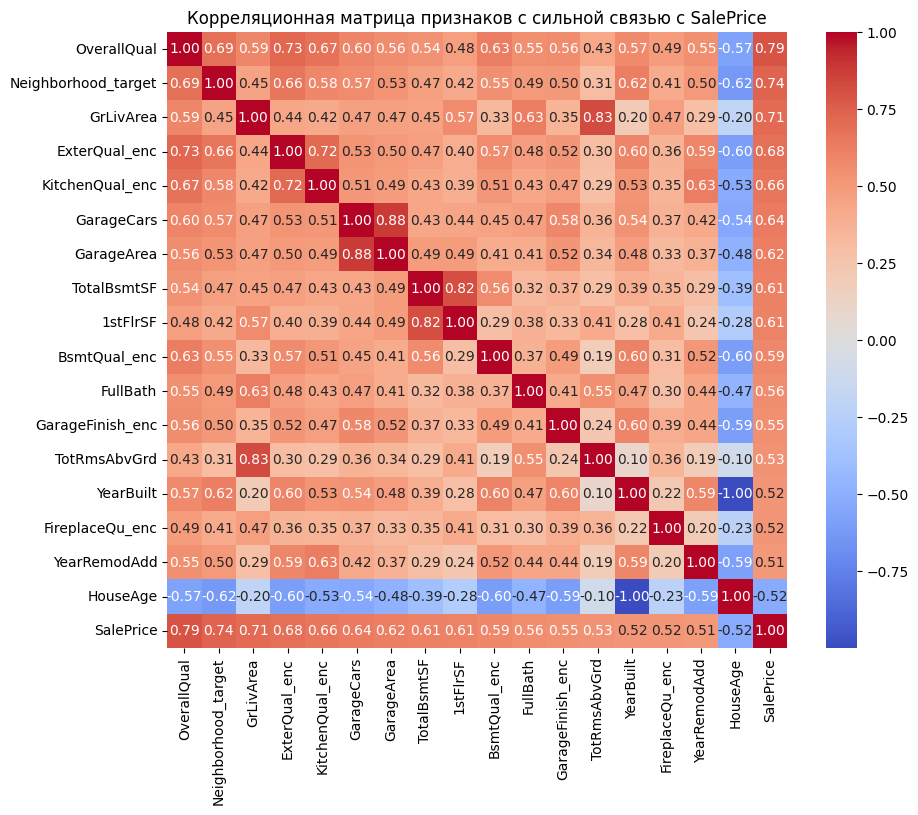

In [34]:
#тепловая карта для признаков с высокой корреляцией
plt.figure(figsize=(10, 8))
corr_data = high_corr_features + ['SalePrice']
sns.heatmap(df2[corr_data].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков с сильной связью с SalePrice')
plt.show()


Из тепловой карты мы можем увидеть корреляцию различных признаков между собой. Можно увидеть, что некоторые признаки линейно-зависимы(HouseAge и YearBuilt; ExterQual_enc и KitchenQual_enc; GarageArea и TotalBsmtSF). Можно задуматья об их удалении

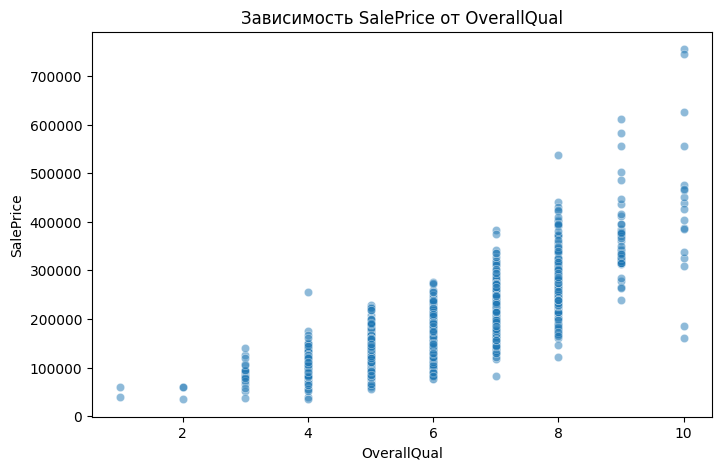

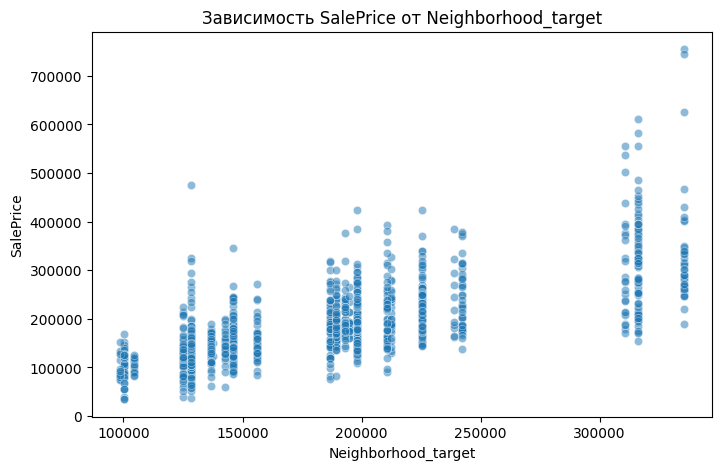

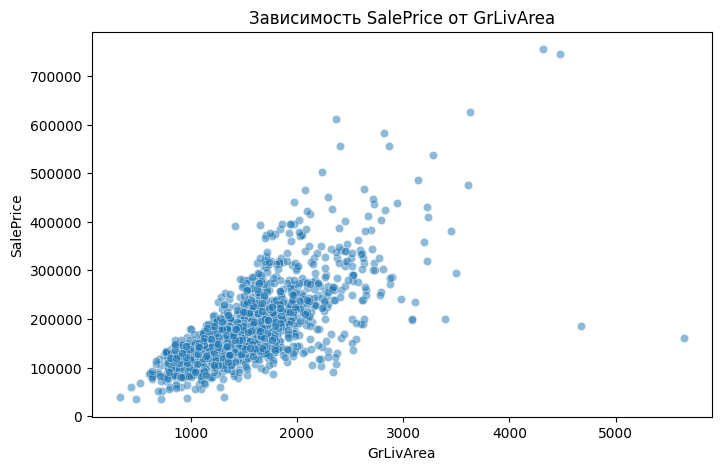

In [35]:
#Scatter plots для для признаков с высокой корреляцией
for col in high_corr_features[:3]:  # ограничим тремя, чтобы не перегружать
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df2, x=col, y='SalePrice', alpha=0.5)
    plt.title(f'Зависимость SalePrice от {col}')
    plt.show()

1. Можно увидеть, что GrLivArea имеет несколько отедльно стоящих точек, которые скорее всего являются выбросами и их можно удалить; либо же это просто нетепичные значения, которые следует в дальнейшем учесть и более грамотно обработать. Остальные признаки размещены облаком, в котором прослеживается слабая линейная зависимостб
2. У остальных признаков прослеживается линейная зависимость с небольшими выбросами

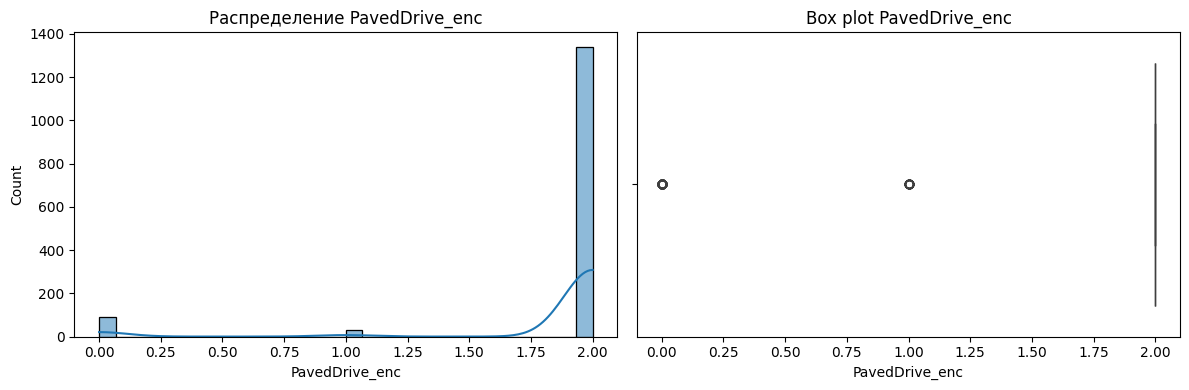

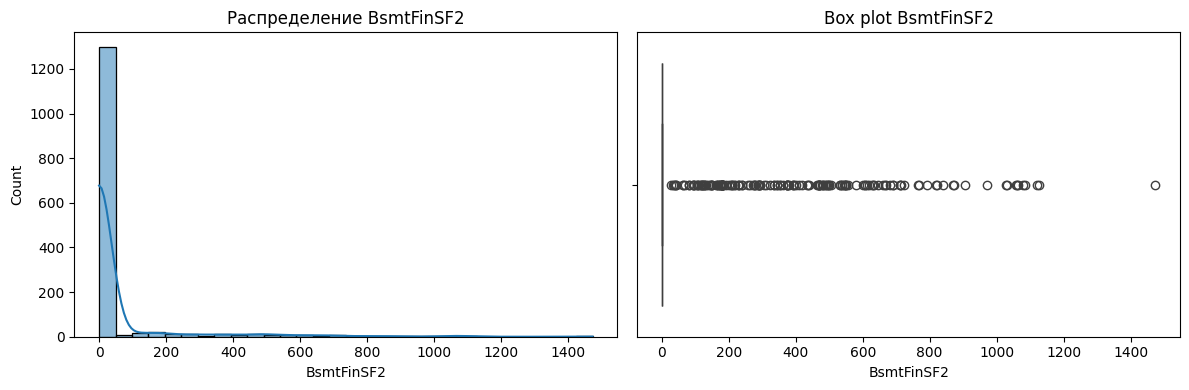

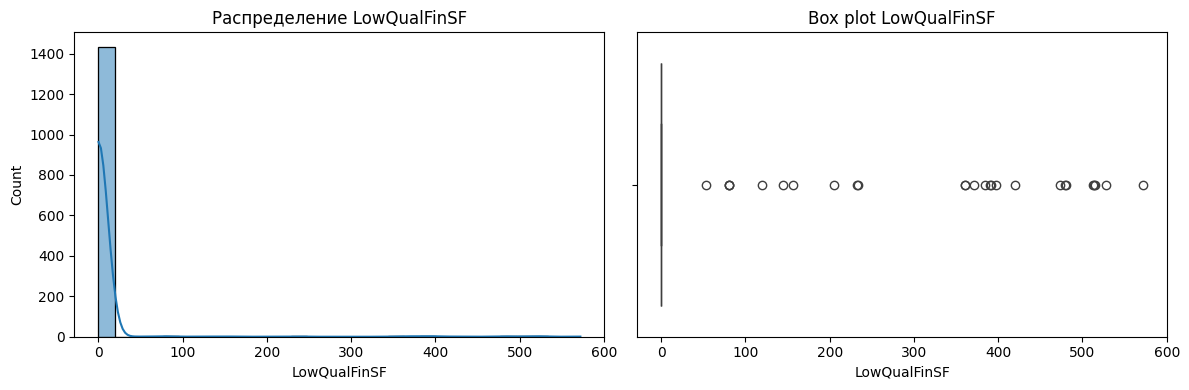

In [36]:
#Гистограмма и BoxPlot для признаков с сильными выбросами
for col in outlier_features[:3]:  # первые три
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    # Гистограмма
    sns.histplot(df2[col].dropna(), bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение {col}')
    # Box plot
    sns.boxplot(x=df2[col], ax=axes[1])
    axes[1].set_title(f'Box plot {col}')
    plt.tight_layout()
    plt.show()

1. Для 1 графика(LotFrontage) можно увидеть что большигнство данных сконсолидированы в одном диапозоне, но также мы имеем некоторые выбросы, которые возможно потребуется обработать
2. Для 2 графика(BsmtFinSF2) видно что практически все данные находятся на значении 0, при этом есть значительная полоска выбросов со огромными значениями сильно отличающимися от 0; их надо будет обработать и правильно масштабировать чтобы они правильно влияли на нашу будущую модель
3. Для 3 графика(HasGarage) мы видим что большинство домов имеет гараж за редким исключением

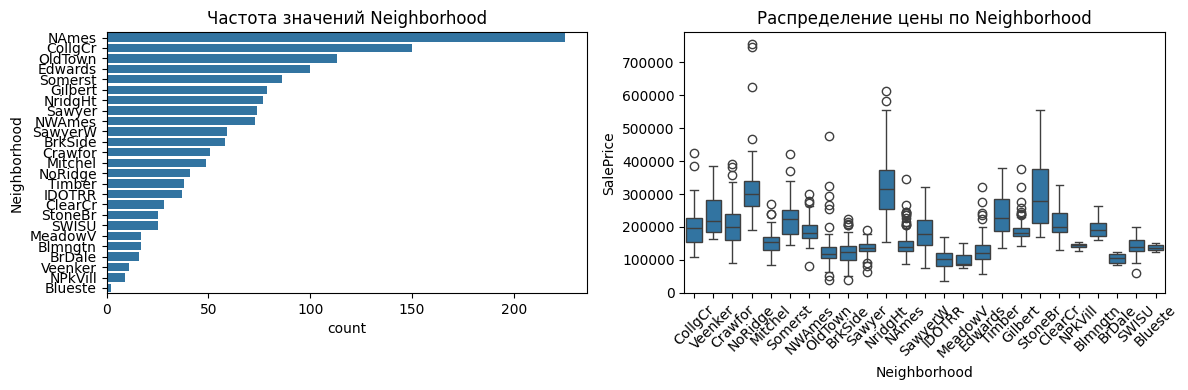

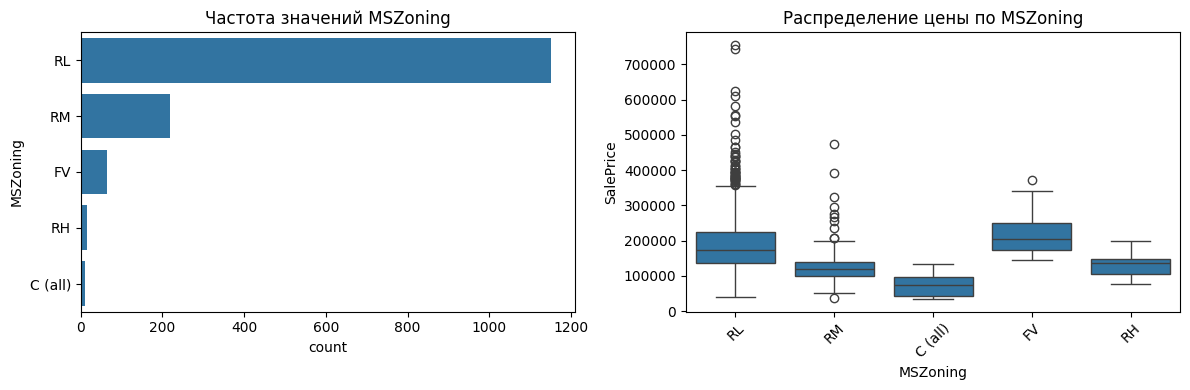

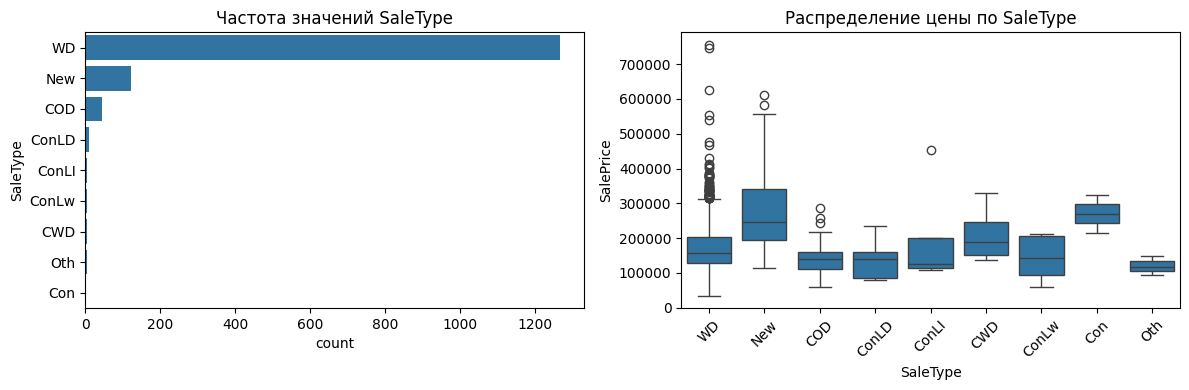

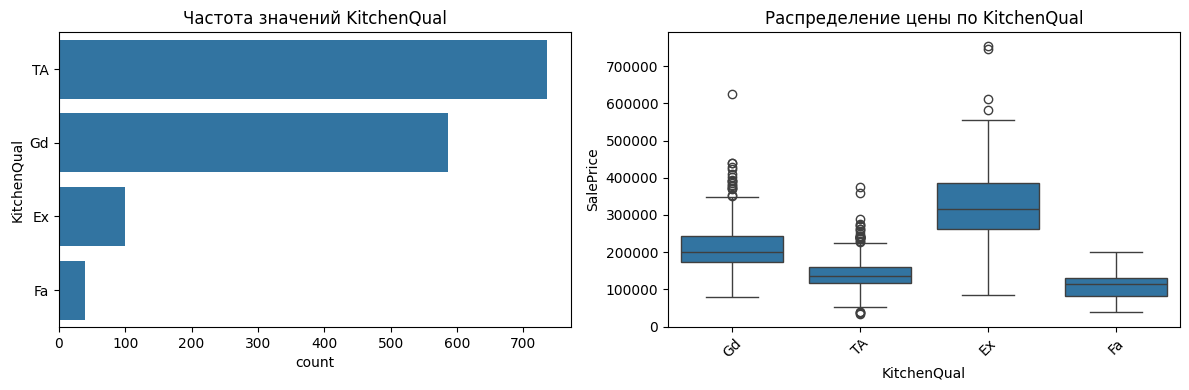

In [37]:
#визуализация важных категориальных признаков 
for cat in important_cats:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    # Count plot
    sns.countplot(y=cat, data=df, order=df[cat].value_counts().index)
    plt.title(f'Частота значений {cat}')
    plt.subplot(1,2,2)
    # Box plot SalePrice по категориям
    sns.boxplot(x=cat, y='SalePrice', data=df)
    plt.xticks(rotation=45)
    plt.title(f'Распределение цены по {cat}')
    plt.tight_layout()
    plt.show()



1. Neighborhood . Видим разницу в цене между самыми богатыми и бедными районами(в 2-3 раза). Также некоторые районы имеют очень дорогую цену некоторых домов, что может чуть неправильно представлять настоящую картину. Также некоторые районы(Blueste) имеют очень мало домов, что может давать не совсем корректную информацию. В целом можно проследить изменение цен на дома относительно их района
2. MSZoning. Видим что некоторые категории имеют очень мало домов, что может давать нам некорректную информацию. Следует объеденить их в отдельную категорию 'other'
3. SaleType. Параметр WD имеет очень большой разброс цены, но медианная цена ние чем в New. Есть много малоинформативных значений, которые лучше объеденить в значение "other"
4. KitchenQual. Четко видно, что чем выше качество тем выше цена

Пункт F

Буллеты:
1. Датасет имеет большое количество пропусков, которые было важно осмысленно заполнить
2. Датасет имеет также очень много категориальных признаков, которые было важно правильно закодировать
3. Мне показалось, что Target encoding намного более понятен и эффективен чем feature hashing(по крайней мере в этом датасете)
4. Датасет имеет некоторые признаки, которые очень сильно коррелируют с целевой переменной 
5. Некоторые признаки линейно-зависимы между собой и их можно удалить
6. Датасет имеет большое количество выбросов, которые требуется грамотно обработать для правильного построения будущей модели.
7. Многие категориальные признаки содержали редкие категории, которые лучше объеденить в один тип 'other'


Гипотезы:
1. Качество отделки (OverallQual) влияет на цену сильнее, чем размер дома. Несмотря на то, что корреляция площади тоже высока, при одинаковой площади дом с более высоким качеством всегда стоит дороже. 
2. Возраст дома (HouseAge) влияет на цену нелинейно. Новые дома (0–10 лет) дорогие, затем цена падает, но после 50–60 лет может снова расти (историческая ценность). Простая линейная корреляция (-0.52) не отражает этой нелинейности, поэтому может потребоваться добавление квадратичного члена или разбиение на категории.
3. Редкие категории в признаках (MiscVal, PoolArea) создают экстремальные выбросы, но они информативны. Дома с бассейнами или дорогими пристройками действительно стоят дороже, и модель должна уметь это учитывать, даже если таких домов мало.

Что делать дальше?
Я думаю, что следует построить модель на основе регрессии, которая будет прогнозировать цену домов исходя из имеющихся признаков

Как мне помогал ИИ?
Для работы с данным датасетом я использовал DeepSeek. Он помогал мне с синтаксисом новых библиотек(поскольку я его еще плохо знаю). Также DeepSeek помогал мне лучше находить причинно-следственные связи между различными явлениями по ходу EDA, а также подсказывал что можно сделать дальше. Дал много подробной информации про различные понятия связанные с EDA и статистикой